# Tests GH 25-06 data reader and time series checker

This notebook reads the CSV files from `Tests GH 25-06`, parses the LoRa export format, synchronizes manual group windows with the CSV timestamps when needed, checks mapping quality, and plots RSSI/SNR through time for visual inspection.


In [164]:
# If you run this in Google Colab, authentication is handled in the next cell.
# If you run locally with downloaded CSVs, set LOCAL_DATA_DIR in the config cell.

from __future__ import annotations

import io
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)
plt.style.use("seaborn-v0_8-whitegrid")


In [ ]:
# ---- Configuration ----

DRIVE_FOLDER_ID = "1Egq_nPkzHTInTvNQbOo5O5w5wvAbIAec"  # Tests GH 25-06
LOCAL_DATA_DIR = "D:/Users/user/Documents/GatewayPlacement/TestsGH2506"
ONLY_CSV_FILES = True
CACHE_DIR = Path("data_cache/tests_gh_25_06")
MANUAL_TIME_RANGES_PATH = Path("manual_time_ranges.json")
MESSAGE_SIZE_BYTES = 34

# A normal group starts 4 s before its registered manual start.
# It ends 6 s before the next registered manual start.
START_BEFORE_REGISTERED_SECONDS = 5
END_BEFORE_NEXT_START_SECONDS = 5

# Some structures have an extra group after the normal final group.
# It is identified from the CSV timestamps when the tail data is at least 60 s away.
EXTRA_FINAL_GROUP_GAP_SECONDS = 60

# Apply these explicit corrections to the manual JSON times before mapping.
# Positive values move the manual window later. All structures not listed use 0 s.
MANUAL_TIME_OFFSETS_SECONDS = {
    "R1358": -32,
    "R1183": -32,
    "R1360": -32,
}

# QC expected group counts are derived from the generated windows below.


In [166]:
def running_in_colab() -> bool:
    try:
        import google.colab  # type: ignore
        return True
    except Exception:
        return False


def build_drive_service():
    """Create an authenticated Google Drive v3 service in Colab or a local env."""
    try:
        from googleapiclient.discovery import build
        from googleapiclient.http import MediaIoBaseDownload
    except Exception as exc:
        raise RuntimeError(
            "Missing Google API packages. In Colab they are usually available. "
            "Locally, install google-api-python-client google-auth google-auth-oauthlib."
        ) from exc

    if running_in_colab():
        from google.colab import auth  # type: ignore
        auth.authenticate_user()
        import google.auth
        creds, _ = google.auth.default()
        return build("drive", "v3", credentials=creds), MediaIoBaseDownload

    # Local fallback: use Application Default Credentials if configured with gcloud auth application-default login.
    import google.auth
    creds, _ = google.auth.default(scopes=["https://www.googleapis.com/auth/drive.readonly"])
    return build("drive", "v3", credentials=creds), MediaIoBaseDownload


def list_drive_csv_files(folder_id: str) -> pd.DataFrame:
    service, _ = build_drive_service()
    rows = []
    page_token = None
    query = f"'{folder_id}' in parents and trashed = false"
    if ONLY_CSV_FILES:
        query += " and mimeType = 'text/csv'"
    while True:
        resp = service.files().list(
            q=query,
            fields="nextPageToken, files(id, name, mimeType, size, createdTime, modifiedTime)",
            orderBy="modifiedTime",
            pageSize=1000,
            pageToken=page_token,
            supportsAllDrives=True,
            includeItemsFromAllDrives=True,
        ).execute()
        rows.extend(resp.get("files", []))
        page_token = resp.get("nextPageToken")
        if not page_token:
            break
    return pd.DataFrame(rows)


def download_drive_file_text(file_id: str) -> str:
    service, MediaIoBaseDownload = build_drive_service()
    request = service.files().get_media(fileId=file_id, supportsAllDrives=True)
    fh = io.BytesIO()
    downloader = MediaIoBaseDownload(fh, request)
    done = False
    while not done:
        _, done = downloader.next_chunk()
    return fh.getvalue().decode("utf-8-sig", errors="replace")


def load_file_catalog() -> pd.DataFrame:
    if LOCAL_DATA_DIR:
        paths = sorted(Path(LOCAL_DATA_DIR).glob("*.csv"))
        return pd.DataFrame({
            "id": [None] * len(paths),
            "name": [p.name for p in paths],
            "path": [str(p) for p in paths],
            "mimeType": ["text/csv"] * len(paths),
            "modifiedTime": [pd.Timestamp(p.stat().st_mtime, unit="s").isoformat() for p in paths],
        })
    return list_drive_csv_files(DRIVE_FOLDER_ID)


def read_file_text(row: pd.Series) -> str:
    if LOCAL_DATA_DIR:
        return Path(row["path"]).read_text(encoding="utf-8-sig", errors="replace")

    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    cache_path = CACHE_DIR / f"{row['id']}_{row['name']}"
    if cache_path.exists():
        return cache_path.read_text(encoding="utf-8-sig", errors="replace")
    text = download_drive_file_text(row["id"])
    cache_path.write_text(text, encoding="utf-8")
    return text

In [167]:
def parse_filename_metadata(name: str) -> dict:
    stem = Path(name).stem
    ids = [int(x) for x in re.findall(r"(?<!\d)(\d{3,5})(?!\d)", stem)]
    primary_id = ids[0] if ids else None
    mirror_match = re.search(r"mirror\s*([0-9]{3,5})", stem, flags=re.I)
    mirror_id = int(mirror_match.group(1)) if mirror_match else None
    date_match = re.search(r"(\d{1,2})[-_](\d{1,2})", stem)
    test_date_hint = None
    if date_match:
        test_date_hint = f"2026-{int(date_match.group(2)):02d}-{int(date_match.group(1)):02d}"
    return {
        "file_stem": stem,
        "primary_id": primary_id,
        "mirror_id": mirror_id,
        "test_date_hint": test_date_hint,
    }


def parse_details(details: object) -> dict:
    if pd.isna(details):
        return {}
    parsed = {}
    for line in str(details).splitlines():
        if ":" not in line:
            continue
        key, value = line.split(":", 1)
        key = key.strip().lower().replace(" ", "_").replace("/", "_").replace("(", "").replace(")", "")
        parsed[f"detail_{key}"] = value.strip()
    return parsed


def parse_detail_json(value: object):
    if pd.isna(value) or not str(value).strip():
        return None
    raw = str(value).strip()
    try:
        return json.loads(raw)
    except Exception:
        try:
            return json.loads(raw.replace('""', '"'))
        except Exception:
            return raw


def split_rssi_snr(series: pd.Series) -> pd.DataFrame:
    split = series.fillna("-/").astype(str).str.strip().str.split("/", n=1, expand=True)
    if split.shape[1] == 1:
        split[1] = np.nan
    return pd.DataFrame({
        "rssi": pd.to_numeric(split[0].replace({"-": np.nan, "": np.nan}), errors="coerce"),
        "snr": pd.to_numeric(split[1].replace({"-": np.nan, "": np.nan}), errors="coerce"),
    })


def parse_signal_csv(text: str, file_row: pd.Series) -> tuple[pd.DataFrame, dict]:
    df = pd.read_csv(io.StringIO(text), engine="python")
    df.columns = [c.strip() for c in df.columns]
    name = file_row.get("name", file_row.get("title", "unknown.csv"))
    meta = parse_filename_metadata(name)
    df["source_file"] = name
    df["source_id"] = file_row.get("id", None)
    for key, value in meta.items():
        df[key] = value

    df = df.rename(columns={
        "Device EUI/Group": "device_eui_group",
        "Gateway ID": "gateway_id",
        "RSSI/SNR": "rssi_snr",
        "Fcnt": "fcnt",
        "Type": "type",
        "Time": "time",
        "Details": "details",
        "Frequency": "frequency",
        "Datarate": "datarate",
        "Size": "size",
    })

    df["time"] = pd.to_datetime(df["time"], errors="coerce", utc=True)
    df["time_local"] = df["time"].dt.tz_convert("Europe/Amsterdam")
    df["fcnt"] = pd.to_numeric(df.get("fcnt"), errors="coerce")
    df["frequency"] = pd.to_numeric(df.get("frequency"), errors="coerce")
    df["size"] = pd.to_numeric(df.get("size"), errors="coerce")
    df = pd.concat([df, split_rssi_snr(df.get("rssi_snr", pd.Series(index=df.index, dtype=object)))], axis=1)

    details_df = pd.DataFrame([parse_details(x) for x in df.get("details", pd.Series(index=df.index, dtype=object))])
    if not details_df.empty:
        df = pd.concat([df.reset_index(drop=True), details_df.reset_index(drop=True)], axis=1)
    df["port"] = pd.to_numeric(df.get("detail_port"), errors="coerce")
    df["payload_hex"] = df.get("detail_payloadhex", pd.Series(index=df.index, dtype=object))
    df["detail_json_obj"] = df.get("detail_json", pd.Series(index=df.index, dtype=object)).apply(parse_detail_json)
    df["gpio_in_2"] = df["detail_json_obj"].apply(lambda x: x.get("gpio_in_2") if isinstance(x, dict) else np.nan)
    df["message_text"] = df["detail_json_obj"].apply(lambda x: x.get("text") if isinstance(x, dict) else None)

    parse_info = {
        "measurable_uplink_rows": int((df["time"].notna() & df["rssi"].notna() & df["snr"].notna() & df["type"].astype(str).str.contains("Up", case=False, na=False)).sum())
    }
    return df.sort_values("time"), parse_info

In [168]:
catalog = load_file_catalog()
catalog = catalog.sort_values("modifiedTime", na_position="last").reset_index(drop=True)
catalog

,id,name,path,mimeType,modifiedTime
0,None,25-6_r1354.csv,D:\Users\user\Documents\GatewayPlacement\Tests...,text/csv,2026-06-25T00:03:18
1,None,25-6_r1356.csv,D:\Users\user\Documents\GatewayPlacement\Tests...,text/csv,2026-06-25T00:33:38
2,None,25-6_1185(mirror1356).csv,D:\Users\user\Documents\GatewayPlacement\Tests...,text/csv,2026-06-25T01:03:10
3,None,25-06_1187 (mirror 1354).csv,D:\Users\user\Documents\GatewayPlacement\Tests...,text/csv,2026-06-25T01:30:06
4,None,25-06_1189 (mirror 1352).csv,D:\Users\user\Documents\GatewayPlacement\Tests...,text/csv,2026-06-25T01:54:06
5,None,25-06_1352.csv,D:\Users\user\Documents\GatewayPlacement\Tests...,text/csv,2026-06-25T02:14:30
6,None,25-06-r1358.csv,D:\Users\user\Documents\GatewayPlacement\Tests...,text/csv,2026-06-25T02:39:50
7,None,25-6-r1183(mirror1385).csv,D:\Users\user\Documents\GatewayPlacement\Tests...,text/csv,2026-06-25T02:58:50
8,None,25-06-r1360.csv,D:\Users\user\Documents\GatewayPlacement\Tests...,text/csv,2026-06-25T03:25:52


In [169]:
frames = []
segment_reports = []

for _, row in catalog.iterrows():
    text = read_file_text(row)
    df_one, seg_info = parse_signal_csv(text, row)
    frames.append(df_one)
    segment_reports.append({
        "source_file": row.get("name", row.get("title", "unknown.csv")),
        "rows": len(df_one),
        "uplink_rows": int(df_one["type"].astype(str).str.contains("Up", case=False, na=False).sum()),
        "measurable_rows": int(df_one[["rssi", "snr"]].notna().all(axis=1).sum()),
        "first_time": df_one["time_local"].min(),
        "last_time": df_one["time_local"].max(),
        **seg_info,
    })

raw_loaded_data = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

# Keep only the measurement packets with the expected payload size.
# All mapping, summaries, and plots below use this filtered data.
data = raw_loaded_data[raw_loaded_data["size"].eq(MESSAGE_SIZE_BYTES)].copy()
segment_report = pd.DataFrame(segment_reports)
segment_report[f"rows_size_{MESSAGE_SIZE_BYTES}"] = segment_report["source_file"].map(data.groupby("source_file").size()).fillna(0).astype(int)
segment_report

,source_file,rows,uplink_rows,measurable_rows,first_time,last_time,measurable_uplink_rows,rows_size_34
0,25-6_r1354.csv,156,154,154,2026-06-25 10:06:57+02:00,2026-06-25 11:02:50+02:00,154,84
1,25-6_r1356.csv,128,127,127,2026-06-25 11:06:50+02:00,2026-06-25 11:28:27+02:00,127,65
2,25-6_1185(mirror1356).csv,205,204,204,2026-06-25 11:37:32+02:00,2026-06-25 12:00:42+02:00,204,106
3,25-06_1187 (mirror 1354).csv,144,143,143,2026-06-25 12:08:08+02:00,2026-06-25 12:26:18+02:00,143,66
4,25-06_1189 (mirror 1352).csv,126,126,126,2026-06-25 12:34:13+02:00,2026-06-25 12:46:46+02:00,126,61
5,25-06_1352.csv,137,136,136,2026-06-25 12:55:45+02:00,2026-06-25 13:10:01+02:00,136,70
6,25-06-r1358.csv,173,172,172,2026-06-25 13:19:46+02:00,2026-06-25 13:38:31+02:00,172,89
7,25-6-r1183(mirror1385).csv,138,137,137,2026-06-25 13:41:12+02:00,2026-06-25 13:56:01+02:00,137,80
8,25-06-r1360.csv,193,192,192,2026-06-25 14:03:55+02:00,2026-06-25 14:24:52+02:00,192,90


In [170]:
file_summary = (
    data.groupby(["source_file", "primary_id", "mirror_id"], dropna=False)
    .agg(
        rows=("source_file", "size"),
        first_time=("time_local", "min"),
        last_time=("time_local", "max"),
        uplink_rows=("type", lambda s: s.astype(str).str.contains("Up", case=False, na=False).sum()),
        rssi_median=("rssi", "median"),
        snr_median=("snr", "median"),
    )
    .reset_index()
)
file_summary


,source_file,primary_id,mirror_id,rows,first_time,last_time,uplink_rows,rssi_median,snr_median
0,25-06-r1358.csv,1358,NaN,89,2026-06-25 13:19:50+02:00,2026-06-25 13:38:27+02:00,89,-89.0,10.5
1,25-06-r1360.csv,1360,NaN,90,2026-06-25 14:04:00+02:00,2026-06-25 14:24:32+02:00,90,-88.0,10.0
2,25-06_1187 (mirror 1354).csv,1187,1354.0,66,2026-06-25 12:08:14+02:00,2026-06-25 12:22:37+02:00,66,-94.0,9.2
3,25-06_1189 (mirror 1352).csv,1189,1352.0,61,2026-06-25 12:34:18+02:00,2026-06-25 12:46:17+02:00,61,-94.0,8.8
4,25-06_1352.csv,1352,NaN,70,2026-06-25 12:55:48+02:00,2026-06-25 13:09:29+02:00,70,-94.0,9.1
5,25-6-r1183(mirror1385).csv,1183,1385.0,80,2026-06-25 13:41:16+02:00,2026-06-25 13:55:51+02:00,80,-92.0,9.8
6,25-6_1185(mirror1356).csv,1185,1356.0,106,2026-06-25 11:37:36+02:00,2026-06-25 12:00:31+02:00,106,-97.0,6.8
7,25-6_r1354.csv,1354,NaN,84,2026-06-25 10:07:23+02:00,2026-06-25 11:02:46+02:00,84,-89.5,9.5
8,25-6_r1356.csv,1356,NaN,65,2026-06-25 11:06:54+02:00,2026-06-25 11:25:11+02:00,65,-86.0,10.5


In [171]:
def plot_file_timeseries(df: pd.DataFrame, file_name: str, group_col: str = "manual_group"):
    one = df[df["source_file"] == file_name].sort_values("time_local").copy()
    measured = one[one["type"].astype(str).str.contains("Up", case=False, na=False)]
    if measured.empty:
        print(f"No uplink measurements for {file_name}")
        return

    fig, axes = plt.subplots(2, 1, figsize=(15, 6.5), sharex=True)
    fig.suptitle(file_name, y=0.98, fontsize=14)

    group_values = measured[group_col].dropna().unique() if group_col in measured.columns else []
    for group in group_values:
        chunk = measured[measured[group_col] == group]
        if chunk.empty:
            continue
        axes[0].axvspan(chunk["time_local"].min(), chunk["time_local"].max(), alpha=0.055, color="tab:blue")
        axes[1].axvspan(chunk["time_local"].min(), chunk["time_local"].max(), alpha=0.055, color="tab:blue")

    for port, chunk in measured.groupby("port", dropna=False):
        label = f"Port {int(port)}" if pd.notna(port) else "Port ?"
        axes[0].scatter(chunk["time_local"], chunk["rssi"], s=24, label=label, alpha=0.82)
        axes[1].scatter(chunk["time_local"], chunk["snr"], s=24, label=label, alpha=0.82)

    axes[0].set_ylabel("RSSI (dBm)")
    axes[1].set_ylabel("SNR (dB)")
    axes[1].set_xlabel("Time (Europe/Amsterdam)")
    axes[0].legend(loc="best", ncol=4)
    plt.tight_layout()
    plt.show()


# Raw per-file plotting helper. Run manually after manual assignment if needed:
# plot_file_timeseries(data, catalog["name"].iloc[0])

## Manual Time Mapping

Each manual group starts at the time written in `manual_time_ranges.json`, after applying any explicit structure offset. A packet belongs to group `Gk` when it is between `Gk` start and 8 seconds before `G{k+1}` starts. Everything after the last registered manual time is assigned to a final open-ended group.


In [172]:
MANUAL_CONFIG = json.loads(MANUAL_TIME_RANGES_PATH.read_text(encoding="utf-8"))
TEST_DATE = "2026-06-25"
LOCAL_TZ = "Europe/Amsterdam"


def hhmmss_to_timestamp(value, date=TEST_DATE, tz=LOCAL_TZ):
    """Convert a manual HH:MM:SS value into a timezone-aware timestamp."""
    if value is None or pd.isna(value):
        return pd.NaT
    return pd.Timestamp(f"{date} {value}", tz=tz)


def structure_from_row(row: pd.Series) -> str | None:
    """Get the structure id from the filename metadata already parsed from the CSV name."""
    value = row.get("primary_id")
    if pd.isna(value):
        value = row.get("mirror_id")
    if pd.isna(value):
        return None
    return f"R{int(value)}"


def manual_offset_for(structure_id: str) -> pd.Timedelta:
    """Return the explicit time correction for a structure's manual timestamps."""
    return pd.Timedelta(seconds=MANUAL_TIME_OFFSETS_SECONDS.get(structure_id, 0))


def manual_ranges_to_frame(config: dict) -> pd.DataFrame:
    """Flatten the manual JSON ranges and apply the configured structure offsets."""
    rows = []
    for key, (start, next_start) in config["ranges"].items():
        structure, group = key.split("_G", 1)
        offset = manual_offset_for(structure)
        manual_start = hhmmss_to_timestamp(start)
        manual_next_start = hhmmss_to_timestamp(next_start)
        registered_start = manual_start + offset if pd.notna(manual_start) else pd.NaT
        registered_next_start = manual_next_start + offset if pd.notna(manual_next_start) else pd.NaT
        rows.append({
            "range_key": key,
            "structure_id": structure,
            "manual_group": int(group),
            "manual_offset_s": offset.total_seconds(),
            "start_raw": start,
            "next_start_raw": next_start,
            "manual_start_time": manual_start,
            "manual_next_start_time": manual_next_start,
            "registered_start_time": registered_start,
            "start_time": registered_start - pd.Timedelta(seconds=START_BEFORE_REGISTERED_SECONDS) if pd.notna(registered_start) else pd.NaT,
            "next_start_time": registered_next_start,
        })
    ranges = pd.DataFrame(rows).sort_values(["structure_id", "manual_group"]).reset_index(drop=True)
    ranges["manual_duration_to_next_s"] = (ranges["manual_next_start_time"] - ranges["manual_start_time"]).dt.total_seconds()
    return ranges


raw_data = data.copy()
raw_data["structure_id"] = raw_data.apply(structure_from_row, axis=1)
manual_ranges = manual_ranges_to_frame(MANUAL_CONFIG)

# This table is only for inspection: it shows which structures were shifted.
offset_report = (
    manual_ranges[["structure_id", "manual_offset_s"]]
    .drop_duplicates()
    .sort_values("structure_id")
    .reset_index(drop=True)
)
offset_report


,structure_id,manual_offset_s
0,R1181,0.0
1,R1183,-32.0
2,R1185,0.0
3,R1187,0.0
4,R1189,0.0
5,R1352,0.0
6,R1354,0.0
7,R1356,0.0
8,R1358,-32.0
9,R1360,-32.0


In [173]:
def find_extra_group_start(packet_data: pd.DataFrame, structure_id: str, final_start):
    """Return the timestamp where an extra final group begins, if the tail has a >=60 s gap."""
    tail = packet_data[
        (packet_data["structure_id"] == structure_id)
        & (packet_data["time_local"] >= final_start)
        & packet_data["type"].astype(str).str.contains("Up", case=False, na=False)
    ].sort_values("time_local")
    if tail.empty:
        return pd.NaT

    times = tail["time_local"].dropna().reset_index(drop=True)
    if times.empty:
        return pd.NaT

    if (times.iloc[0] - final_start).total_seconds() >= EXTRA_FINAL_GROUP_GAP_SECONDS:
        return times.iloc[0]

    gaps = times.diff().dt.total_seconds()
    gap_hits = gaps[gaps >= EXTRA_FINAL_GROUP_GAP_SECONDS]
    if gap_hits.empty:
        return pd.NaT
    return times.iloc[gap_hits.index[0]]


def split_extra_final_groups(windows: pd.DataFrame, packet_data: pd.DataFrame) -> pd.DataFrame:
    """Split group 12 into groups 12 and 13 when the CSV tail has a clear >=60 s gap."""
    windows = windows.copy()
    extra_rows = []

    for idx, row in windows[windows["is_final_group"]].iterrows():
        extra_start = find_extra_group_start(packet_data, row["structure_id"], row["start_time"])
        if pd.isna(extra_start):
            continue

        # The existing final group becomes a finite group ending before the extra group starts.
        windows.loc[idx, "effective_next_start_time"] = extra_start
        windows.loc[idx, "valid_end"] = extra_start - pd.Timedelta(seconds=END_BEFORE_NEXT_START_SECONDS)
        windows.loc[idx, "is_final_group"] = False
        windows.loc[idx, "has_complete_window"] = windows.loc[idx, "valid_end"] > windows.loc[idx, "start_time"]

        # The new group is open-ended and receives all packets after the gap.
        new_row = row.copy()
        new_row["range_key"] = f"{row['structure_id']}_G{int(row['manual_group']) + 1}_extra_final"
        new_row["manual_group"] = int(row["manual_group"]) + 1
        new_row["start_time"] = extra_start
        new_row["effective_next_start_time"] = pd.NaT
        new_row["valid_end"] = pd.NaT
        new_row["is_final_group"] = True
        new_row["has_complete_window"] = True
        extra_rows.append(new_row)

    if extra_rows:
        windows = pd.concat([windows, pd.DataFrame(extra_rows)], ignore_index=True)
    return windows


def build_mapping_windows(ranges: pd.DataFrame, packet_data: pd.DataFrame) -> pd.DataFrame:
    """Create the time windows used for assigning CSV packets to manual groups."""
    windows = ranges.copy()

    # Regular groups normally end shortly before the next group starts.
    # If the next start is missing, use the last registered time for that structure.
    last_registered = {}
    for structure_id, group in windows.groupby("structure_id", dropna=False):
        registered = pd.concat([group["registered_start_time"], group["next_start_time"]]).dropna()
        if not registered.empty:
            last_registered[structure_id] = registered.max()

    windows["effective_next_start_time"] = windows.apply(
        lambda row: row["next_start_time"] if pd.notna(row["next_start_time"]) else last_registered.get(row["structure_id"], pd.NaT),
        axis=1,
    )
    windows["valid_end"] = windows["effective_next_start_time"].apply(
        lambda value: value - pd.Timedelta(seconds=END_BEFORE_NEXT_START_SECONDS) if pd.notna(value) else pd.NaT
    )
    windows["is_final_group"] = False
    windows["has_complete_window"] = (
        windows["start_time"].notna()
        & windows["valid_end"].notna()
        & (windows["valid_end"] > windows["start_time"])
    )

    # Add one open-ended final group per structure, starting at the last manual time available.
    final_rows = []
    for structure_id, group in windows.groupby("structure_id", dropna=False):
        registered_times = pd.concat([group["registered_start_time"], group["next_start_time"]]).dropna()
        if registered_times.empty:
            continue
        final_registered_start = registered_times.max()
        final_start = final_registered_start - pd.Timedelta(seconds=START_BEFORE_REGISTERED_SECONDS)
        final_group = int(group["manual_group"].max()) + 1
        final_rows.append({
            "range_key": f"{structure_id}_G{final_group}_final",
            "structure_id": structure_id,
            "manual_group": final_group,
            "manual_offset_s": group["manual_offset_s"].dropna().iloc[0] if group["manual_offset_s"].notna().any() else 0,
            "start_raw": None,
            "next_start_raw": None,
            "manual_start_time": pd.NaT,
            "manual_next_start_time": pd.NaT,
            "registered_start_time": final_registered_start,
            "start_time": final_start,
            "next_start_time": pd.NaT,
            "effective_next_start_time": pd.NaT,
            "manual_duration_to_next_s": np.nan,
            "valid_end": pd.NaT,
            "is_final_group": True,
            "has_complete_window": True,
        })

    if final_rows:
        windows = pd.concat([windows, pd.DataFrame(final_rows)], ignore_index=True)

    windows = split_extra_final_groups(windows, packet_data)

    windows["window_duration_s"] = windows.apply(
        lambda row: (row["valid_end"] - row["start_time"]).total_seconds() if pd.notna(row["valid_end"]) and pd.notna(row["start_time"]) else np.nan,
        axis=1,
    )
    windows.loc[windows["is_final_group"], "window_duration_s"] = np.nan
    windows.loc[~windows["has_complete_window"], "window_duration_s"] = np.nan
    return windows.sort_values(["structure_id", "manual_group", "is_final_group"]).reset_index(drop=True)


mapping_windows = build_mapping_windows(manual_ranges, raw_data)
mapping_windows[[
    "structure_id", "manual_group", "manual_offset_s", "start_time", "valid_end", "is_final_group", "has_complete_window"
]].head(30)


,structure_id,manual_group,manual_offset_s,start_time,valid_end,is_final_group,has_complete_window
0,R1181,1,0.0,2026-06-25 14:46:42+02:00,2026-06-25 14:46:49+02:00,False,True
1,R1181,2,0.0,2026-06-25 14:46:51+02:00,2026-06-25 14:47:41+02:00,False,True
2,R1181,3,0.0,2026-06-25 14:47:43+02:00,2026-06-25 14:48:34+02:00,False,True
3,R1181,4,0.0,2026-06-25 14:48:36+02:00,2026-06-25 14:49:06+02:00,False,True
4,R1181,5,0.0,2026-06-25 14:49:08+02:00,2026-06-25 14:50:04+02:00,False,True
5,R1181,6,0.0,2026-06-25 14:50:06+02:00,2026-06-25 14:51:34+02:00,False,True
6,R1181,7,0.0,2026-06-25 14:51:36+02:00,2026-06-25 15:31:38+02:00,False,True
7,R1181,8,0.0,2026-06-25 15:31:40+02:00,2026-06-25 15:32:28+02:00,False,True
8,R1181,9,0.0,2026-06-25 15:32:30+02:00,2026-06-25 15:33:40+02:00,False,True
9,R1181,10,0.0,2026-06-25 15:33:42+02:00,2026-06-25 15:37:08+02:00,False,True


In [174]:
def match_manual_group(time_value, structure_id: str | None, windows: pd.DataFrame):
    """Assign one CSV timestamp to one manual group, or flag why it cannot be assigned."""
    if structure_id is None or pd.isna(structure_id):
        return pd.Series({"manual_group": pd.NA, "manual_group_status": "file_structure_unknown", "manual_group_reliable": False})
    if pd.isna(time_value):
        return pd.Series({"manual_group": pd.NA, "manual_group_status": "missing_time", "manual_group_reliable": False})

    sub = windows[(windows["structure_id"] == structure_id) & (windows["has_complete_window"])]
    if sub.empty:
        return pd.Series({"manual_group": pd.NA, "manual_group_status": "no_complete_manual_window_for_structure", "manual_group_reliable": False})

    # First try finite windows: start <= packet time < next_start - 8 s.
    regular = sub[~sub["is_final_group"]]
    matches = regular[(regular["start_time"] <= time_value) & (time_value < regular["valid_end"])]

    # If no finite group matches, try the open-ended final group.
    if matches.empty:
        final = sub[sub["is_final_group"]]
        matches = final[final["start_time"] <= time_value]

    if len(matches) == 1:
        status = "assigned_final_group" if bool(matches.iloc[0]["is_final_group"]) else "assigned_manual_window"
        return pd.Series({"manual_group": int(matches.iloc[0]["manual_group"]), "manual_group_status": status, "manual_group_reliable": True})
    if len(matches) > 1:
        groups = ",".join(matches["manual_group"].astype(str))
        return pd.Series({"manual_group": pd.NA, "manual_group_status": f"ambiguous_manual_window_overlap:{groups}", "manual_group_reliable": False})

    nearest = sub.iloc[(sub["start_time"] - time_value).abs().argsort()[:1]]
    if not nearest.empty:
        delta_s = abs((time_value - nearest.iloc[0]["start_time"]).total_seconds())
        return pd.Series({"manual_group": pd.NA, "manual_group_status": f"outside_manual_window_nearest_G{int(nearest.iloc[0]['manual_group'])}_{delta_s:.1f}s", "manual_group_reliable": False})
    return pd.Series({"manual_group": pd.NA, "manual_group_status": "outside_manual_windows", "manual_group_reliable": False})


def add_manual_groups(df: pd.DataFrame, windows: pd.DataFrame) -> pd.DataFrame:
    """Attach manual group assignments and the offset used for each structure."""
    out = df.copy()
    assigned = out.apply(lambda row: match_manual_group(row["time_local"], row["structure_id"], windows), axis=1)
    out = pd.concat([out, assigned], axis=1)
    out["manual_group"] = out["manual_group"].astype("Int64")
    out["manual_group_reliable"] = out["manual_group_reliable"].astype(bool)
    offsets = windows[["structure_id", "manual_offset_s"]].drop_duplicates()
    out = out.merge(offsets, on="structure_id", how="left")
    return out


mapped_data = add_manual_groups(raw_data, mapping_windows)
data = mapped_data

manual_assignment_report = (
    mapped_data.groupby(["source_file", "structure_id", "manual_offset_s", "manual_group_status", "manual_group_reliable"], dropna=False)
    .size()
    .reset_index(name="rows")
    .sort_values(["source_file", "manual_group_reliable", "manual_group_status"], ascending=[True, False, True])
)
manual_assignment_report


,source_file,structure_id,manual_offset_s,manual_group_status,manual_group_reliable,rows
0,25-06-r1358.csv,R1358,-32.0,assigned_final_group,True,29
1,25-06-r1358.csv,R1358,-32.0,assigned_manual_window,True,60
2,25-06-r1360.csv,R1360,-32.0,assigned_final_group,True,37
3,25-06-r1360.csv,R1360,-32.0,assigned_manual_window,True,53
4,25-06_1187 (mirror 1354).csv,R1187,0.0,assigned_manual_window,True,66
5,25-06_1189 (mirror 1352).csv,R1189,0.0,assigned_final_group,True,1
6,25-06_1189 (mirror 1352).csv,R1189,0.0,assigned_manual_window,True,60
7,25-06_1352.csv,R1352,0.0,assigned_final_group,True,4
8,25-06_1352.csv,R1352,0.0,assigned_manual_window,True,65
9,25-06_1352.csv,R1352,0.0,outside_manual_window_nearest_G10_2.0s,False,1


In [175]:
def expected_group_counts(windows: pd.DataFrame) -> pd.DataFrame:
    """Expected groups come from the generated windows, including any detected group 13."""
    return (
        windows.groupby("structure_id", dropna=False)["manual_group"]
        .nunique()
        .reset_index(name="expected_groups")
    )


def summarize_manual_groups(df: pd.DataFrame) -> pd.DataFrame:
    """Summarize RSSI/SNR stability for every mapped structure and group."""
    measured = df[df["type"].astype(str).str.contains("Up", case=False, na=False)].copy()
    measured = measured[measured["manual_group"].notna()]
    if measured.empty:
        return pd.DataFrame()

    def mad(series):
        series = series.dropna()
        if series.empty:
            return np.nan
        return float((series - series.median()).abs().median())

    return (
        measured.groupby(["structure_id", "manual_offset_s", "manual_group", "manual_group_status"], dropna=False)
        .agg(
            samples=("rssi", "count"),
            first_time=("time_local", "min"),
            last_time=("time_local", "max"),
            rssi_median=("rssi", "median"),
            rssi_mad=("rssi", mad),
            snr_median=("snr", "median"),
            snr_mad=("snr", mad),
        )
        .reset_index()
        .sort_values(["structure_id", "manual_group"])
    )


manual_group_summary = summarize_manual_groups(mapped_data)

expected_group_report = (
    manual_group_summary.groupby("structure_id", dropna=False)
    .agg(assigned_groups=("manual_group", "nunique"), samples=("samples", "sum"))
    .reset_index()
    .merge(offset_report, on="structure_id", how="left")
)
expected_group_report = expected_group_report.merge(expected_group_counts(mapping_windows), on="structure_id", how="left")
expected_group_report["missing_groups"] = expected_group_report["expected_groups"] - expected_group_report["assigned_groups"]
expected_group_report["mapping_count_ok"] = expected_group_report["missing_groups"].eq(0)

manual_group_summary, expected_group_report


(    structure_id  manual_offset_s  manual_group     manual_group_status  samples                first_time                 last_time  rssi_median  rssi_mad  snr_median  snr_mad
 0          R1183            -32.0             1  assigned_manual_window        4 2026-06-25 13:41:16+02:00 2026-06-25 13:41:44+02:00        -47.0       4.5       13.60     0.50
 1          R1183            -32.0             2  assigned_manual_window        6 2026-06-25 13:41:53+02:00 2026-06-25 13:42:48+02:00        -58.5       1.0       12.90     1.35
 2          R1183            -32.0             3  assigned_manual_window        5 2026-06-25 13:43:05+02:00 2026-06-25 13:43:28+02:00        -74.0       2.0       13.80     0.20
 3          R1183            -32.0             4  assigned_manual_window        5 2026-06-25 13:43:57+02:00 2026-06-25 13:44:27+02:00        -93.0       2.0        9.80     4.20
 4          R1183            -32.0             5  assigned_manual_window        6 2026-06-25 13:44:41+02:00 20

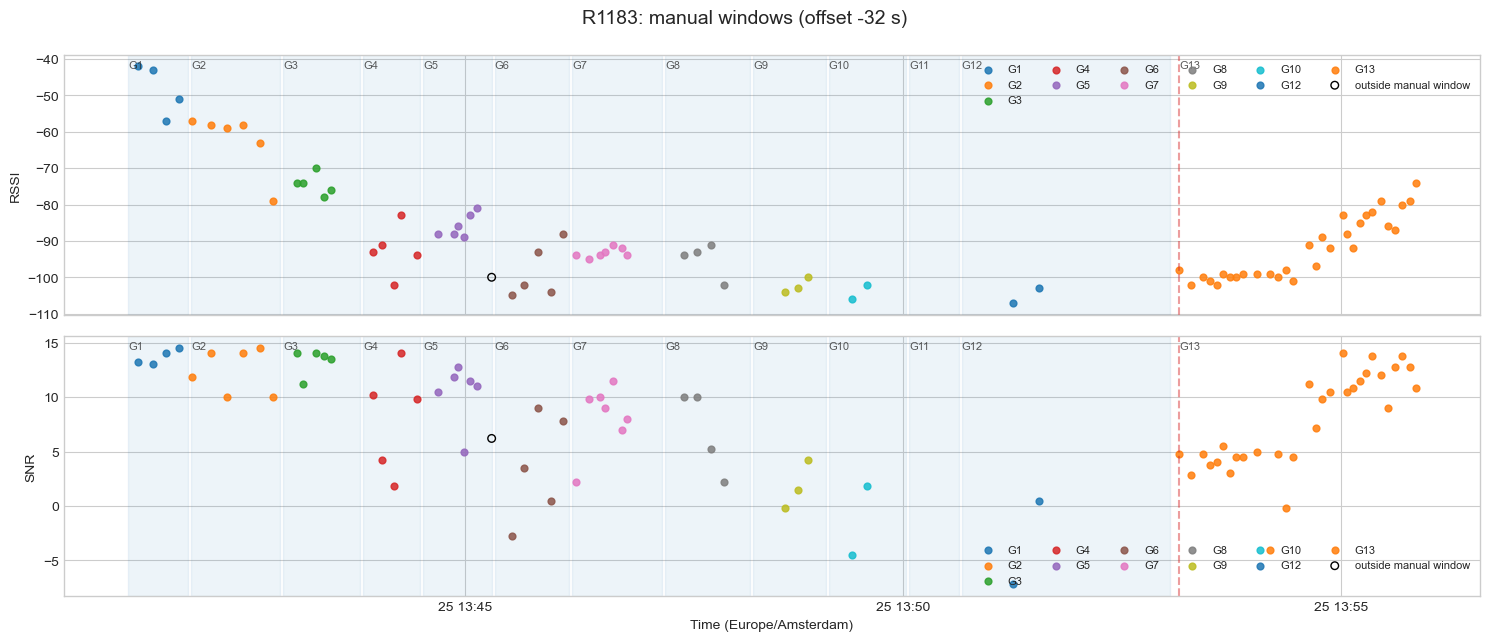

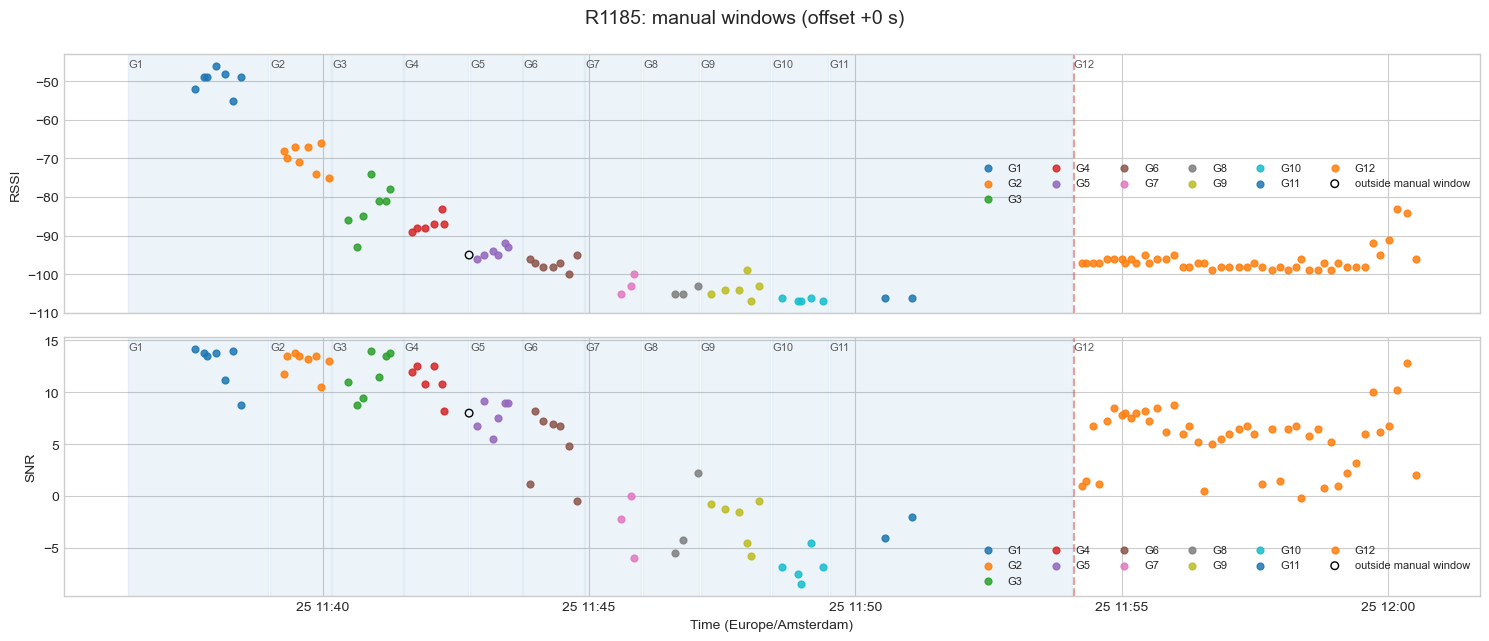

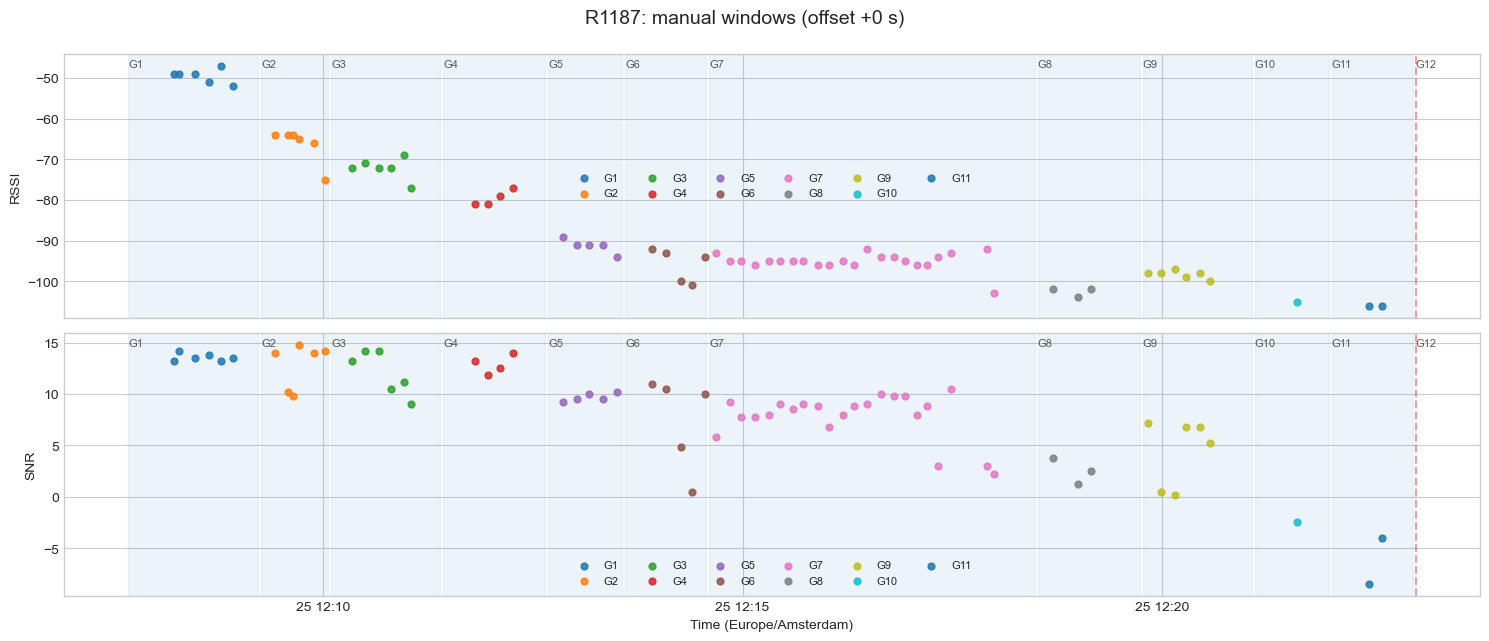

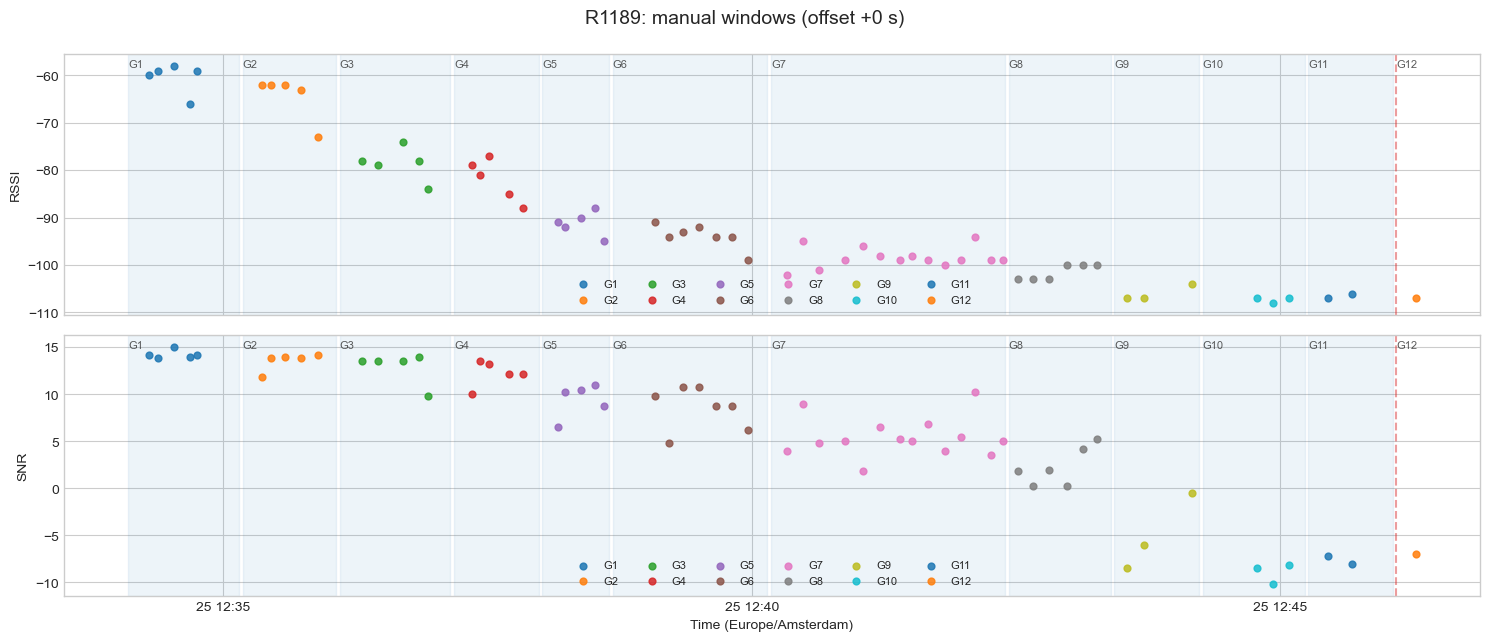

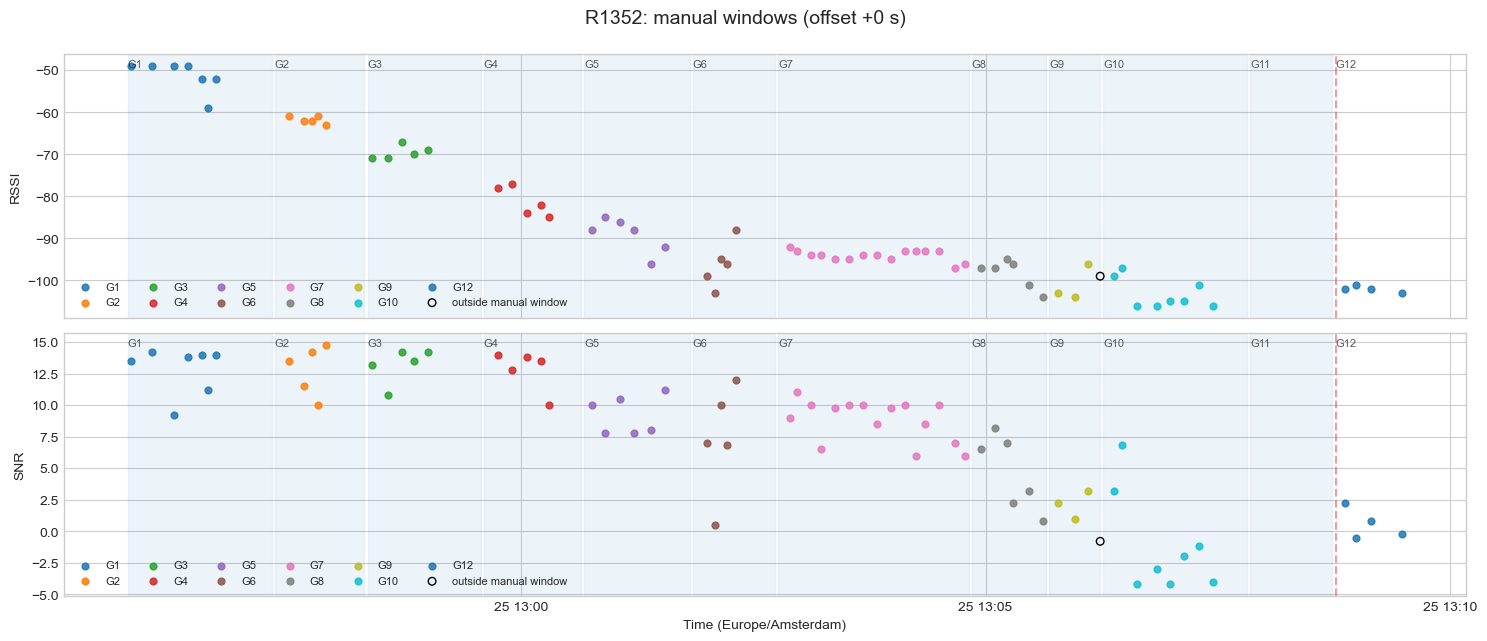

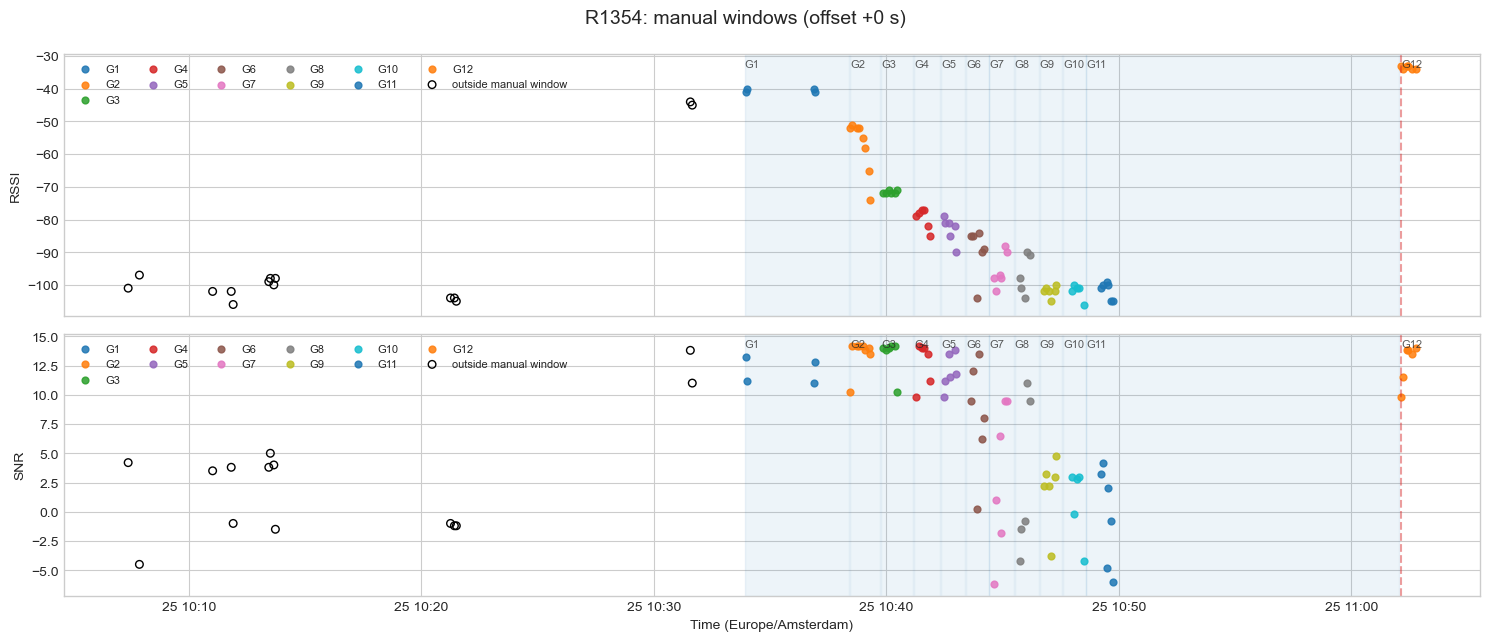

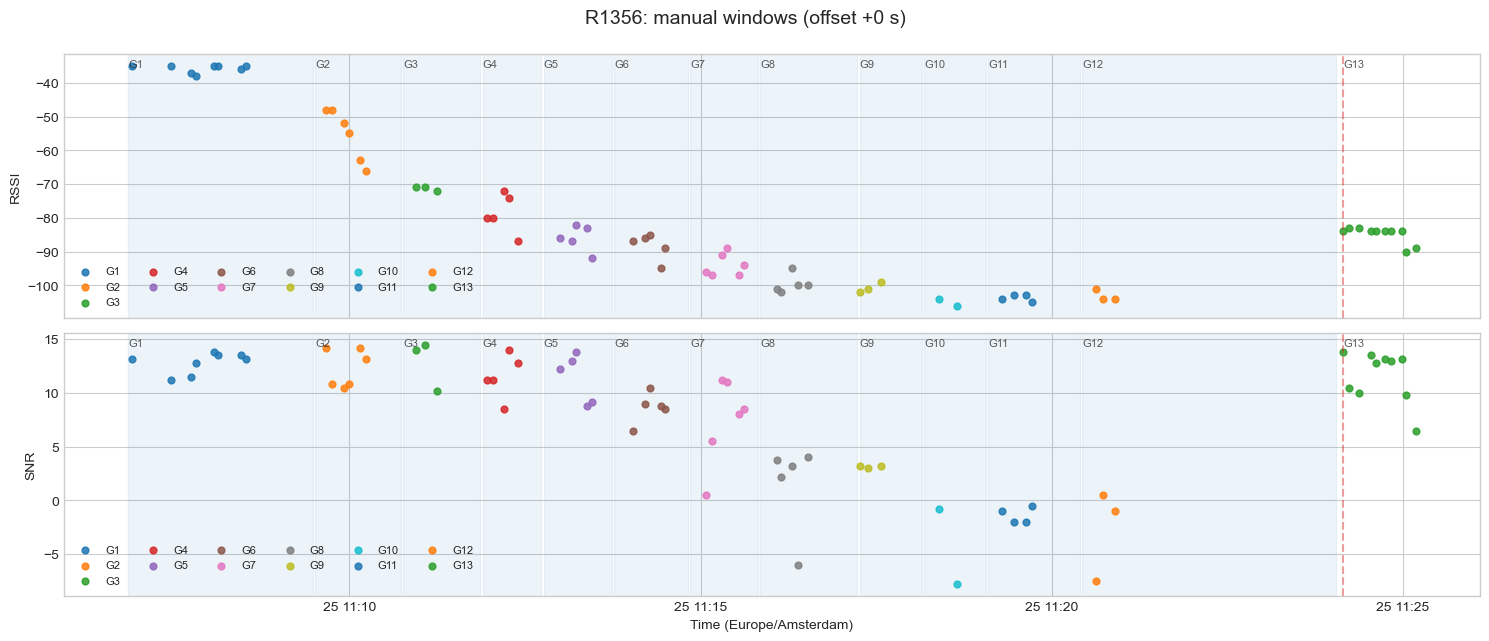

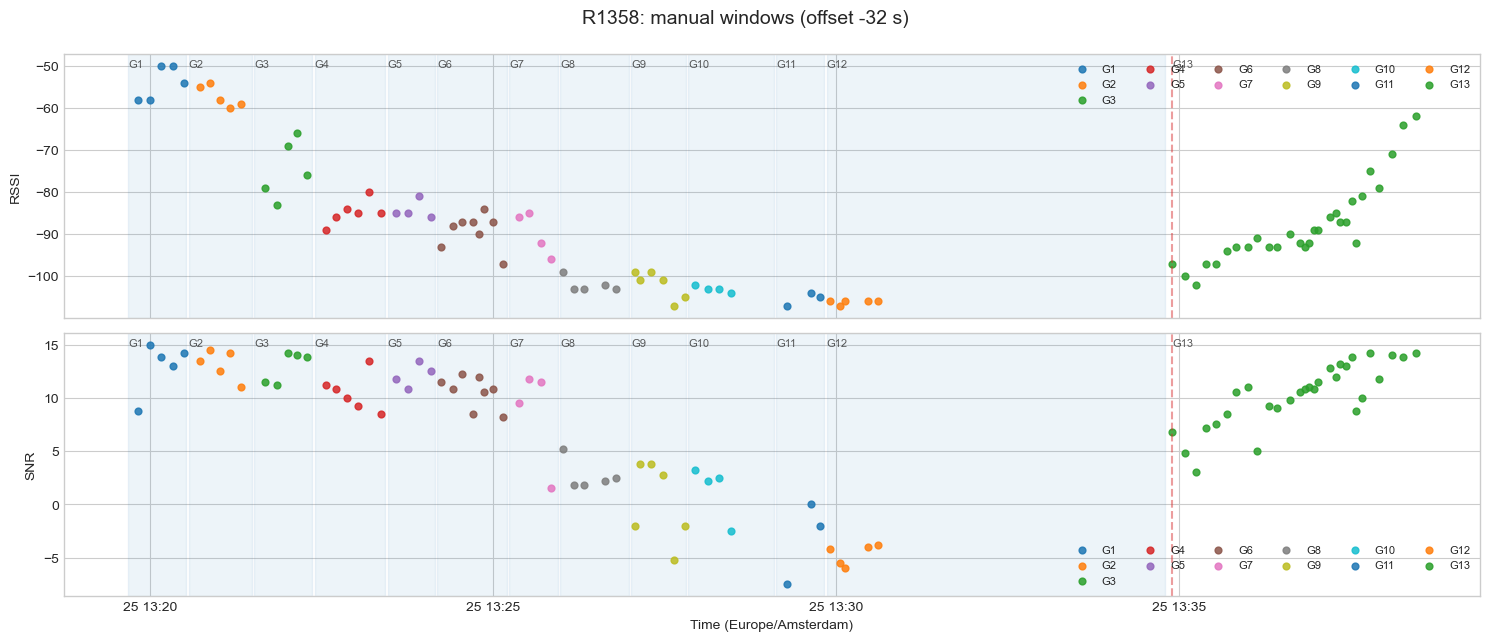

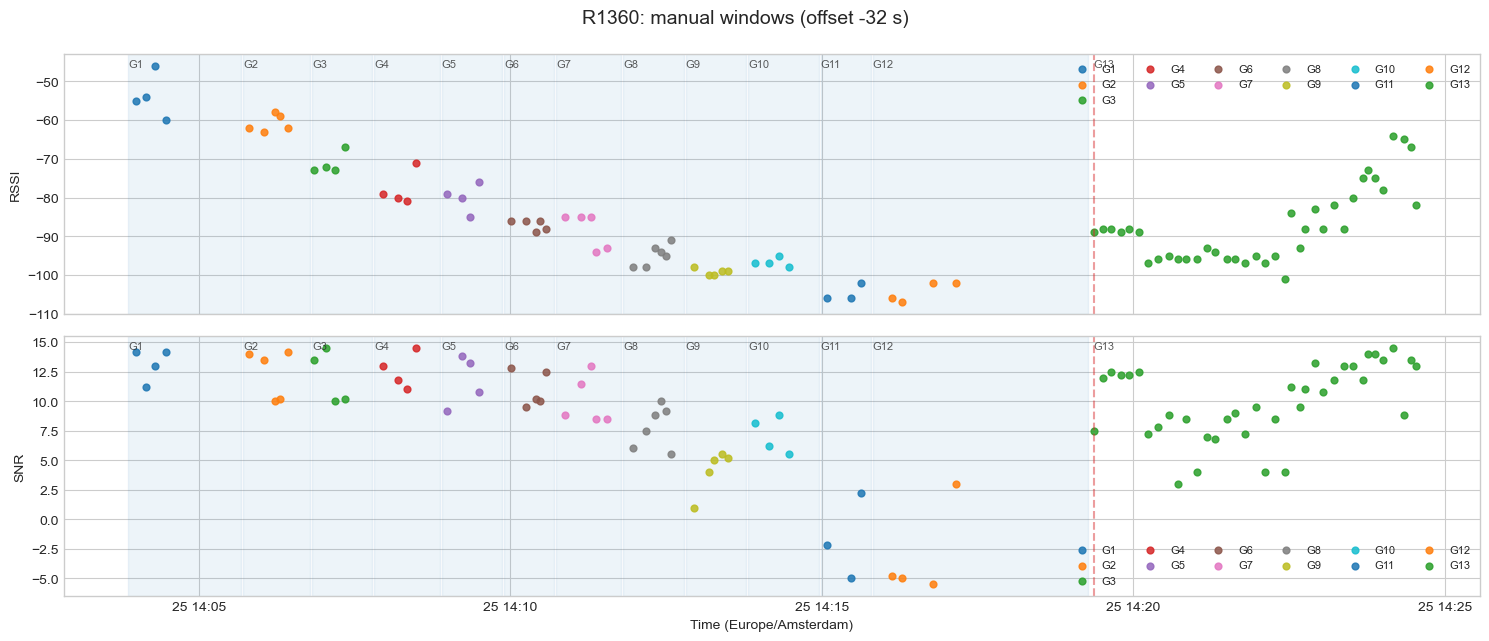

In [176]:
def plot_manual_timeseries(df: pd.DataFrame, structure_id: str, metric_cols=("rssi", "snr")):
    one = df[(df["structure_id"] == structure_id) & df["type"].astype(str).str.contains("Up", case=False, na=False)].copy()
    one = one.sort_values("time_local")
    if one.empty:
        print(f"No uplink rows found for {structure_id}")
        return
    offset_s = one["manual_offset_s"].dropna().iloc[0] if one["manual_offset_s"].notna().any() else 0
    fig, axes = plt.subplots(len(metric_cols), 1, figsize=(15, 3.2 * len(metric_cols)), sharex=True)
    if len(metric_cols) == 1:
        axes = [axes]
    fig.suptitle(f"{structure_id}: manual windows (offset {offset_s:+.0f} s)", fontsize=14, y=0.995)
    ranges = mapping_windows[mapping_windows["structure_id"] == structure_id]
    for ax in axes:
        for _, rr in ranges.iterrows():
            if not bool(rr["has_complete_window"]):
                continue
            if bool(rr["is_final_group"]):
                ax.axvline(rr["start_time"], color="tab:red", alpha=0.45, linestyle="--")
            else:
                ax.axvspan(rr["start_time"], rr["valid_end"], color="tab:blue", alpha=0.08)
            ax.text(rr["start_time"], 0.98, f"G{int(rr['manual_group'])}", transform=ax.get_xaxis_transform(), va="top", fontsize=8, alpha=0.75)
    reliable = one[one["manual_group_reliable"]]
    unreliable = one[~one["manual_group_reliable"]]
    for ax, metric in zip(axes, metric_cols):
        for group, chunk in reliable.groupby("manual_group"):
            ax.scatter(chunk["time_local"], chunk[metric], s=24, label=f"G{int(group)}", alpha=0.86)
        if not unreliable.empty:
            ax.scatter(unreliable["time_local"], unreliable[metric], s=30, facecolors="none", edgecolors="black", label="outside manual window")
        ax.set_ylabel(metric.upper())
        ax.legend(loc="best", ncol=6, fontsize=8)
    axes[-1].set_xlabel("Time (Europe/Amsterdam)")
    plt.tight_layout()
    plt.show()


for structure_id in sorted(mapped_data["structure_id"].dropna().unique()):
    plot_manual_timeseries(mapped_data, structure_id)
